## Business Scenario

The product team hypothesised that customers paying in
installments (credit) have lower satisfaction and higher
cancellation rates than customers paying upfront (debit/voucher).

They proposed a new checkout experience for installment
customers — clearer fee disclosure and a recommended
installment count — to reduce cancellations and improve
satisfaction.

### Experiment Design
- Control group   : Customers who paid with credit card
                    (standard checkout — existing experience)
- Treatment group : Customers who paid with debit card
                    or voucher (simplified, upfront checkout)

- Primary metric  : Order cancellation rate (lower = better)
- Secondary metric: Average review score (higher = better)
- Tertiary metric : Average order value

### Hypothesis
H0 (null)     : There is no difference in cancellation rate
                between the two checkout experiences
H1 (alternate): The simplified checkout has a lower
                cancellation rate than standard checkout

### Significance level: α = 0.05

In [3]:
!pip3 install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 20.3 MB/s  0:00:00.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

con = duckdb.connect('../data/olist.duckdb')

con.execute("""
    CREATE OR REPLACE VIEW master AS
    SELECT * FROM read_parquet('../data/master_orders.parquet')
""")

print("✓ Connected to DuckDB")

✓ Connected to DuckDB


In [2]:
ab_data = con.execute("""
    WITH experiment AS (
        SELECT
            order_id,
            customer_id,
            order_status,
            total_payment,
            review_score,
            payment_type,
            purchase_year,
            yearmon,

            -- Define groups
            CASE
                WHEN payment_type = 'credit_card'
                THEN 'control'
                WHEN payment_type IN ('debit_card', 'voucher')
                THEN 'treatment'
                ELSE NULL
            END                                         AS ab_group,

            -- Primary metric: was the order cancelled?
            CASE
                WHEN order_status IN ('canceled','unavailable')
                THEN 1 ELSE 0
            END                                         AS is_cancelled,

            -- Did order convert successfully?
            CASE
                WHEN order_status = 'delivered'
                THEN 1 ELSE 0
            END                                         AS is_delivered

        FROM master
        WHERE purchase_year IN (2017, 2018)
          AND total_payment  IS NOT NULL
          AND payment_type   IN ('credit_card','debit_card','voucher')
    )

    SELECT * FROM experiment
    WHERE ab_group IS NOT NULL

""").df()

# Register for further SQL queries
con.register('ab_data', ab_data)

print(f"Total experiment observations : {len(ab_data):,}")
print(f"\nGroup sizes:")
print(ab_data['ab_group'].value_counts())

Total experiment observations : 79,388

Group sizes:
ab_group
control      75132
treatment     4256
Name: count, dtype: int64


In [3]:
group_stats = con.execute("""
    SELECT
        ab_group                                        AS group_name,
        COUNT(*)                                        AS total_orders,
        SUM(is_cancelled)                               AS cancelled_orders,
        ROUND(100.0 * SUM(is_cancelled) / COUNT(*), 3) AS cancel_rate_pct,
        ROUND(100.0 * SUM(is_delivered) / COUNT(*), 3) AS delivery_rate_pct,
        ROUND(AVG(total_payment), 2)                    AS avg_order_value,
        ROUND(AVG(review_score), 3)                     AS avg_review_score,
        ROUND(STDDEV(total_payment), 2)                 AS stddev_order_value,
        ROUND(STDDEV(review_score), 3)                  AS stddev_review

    FROM ab_data
    GROUP BY ab_group
    ORDER BY ab_group DESC

""").df()

print("\nA/B GROUP SUMMARY STATISTICS")
print("=" * 60)
print(group_stats.to_string(index=False))


A/B GROUP SUMMARY STATISTICS
group_name  total_orders  cancelled_orders  cancel_rate_pct  delivery_rate_pct  avg_order_value  avg_review_score  stddev_order_value  stddev_review
 treatment          4256             119.0            2.796             95.348           135.50             4.067              216.30          1.369
   control         75132             837.0            1.114             97.180           166.55             4.090              224.15          1.345


In [4]:
# Extract values for the test
control   = ab_data[ab_data['ab_group'] == 'control']
treatment = ab_data[ab_data['ab_group'] == 'treatment']

n_ctrl    = len(control)
n_trt     = len(treatment)
cancel_ctrl = control['is_cancelled'].sum()
cancel_trt  = treatment['is_cancelled'].sum()

rate_ctrl = cancel_ctrl / n_ctrl
rate_trt  = cancel_trt  / n_trt

print(f"Control   — cancellation rate: {rate_ctrl*100:.3f}% ({cancel_ctrl:,}/{n_ctrl:,})")
print(f"Treatment — cancellation rate: {rate_trt*100:.3f}% ({cancel_trt:,}/{n_trt:,})")
print(f"Absolute difference           : {(rate_ctrl - rate_trt)*100:.3f} pp")
print(f"Relative improvement          : {(rate_ctrl - rate_trt)/rate_ctrl*100:.1f}%")

# Two-proportion z-test
counts = np.array([cancel_ctrl, cancel_trt])
nobs   = np.array([n_ctrl, n_trt])

z_stat, p_value = proportions_ztest(
    counts, nobs,
    alternative='larger'  # H1: control cancels MORE than treatment
)

print(f"\nZ-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print(f"Significant : {'YES ✓' if p_value < 0.05 else 'NO ✗'} (α = 0.05)")

Control   — cancellation rate: 1.114% (837/75,132)
Treatment — cancellation rate: 2.796% (119/4,256)
Absolute difference           : -1.682 pp
Relative improvement          : -151.0%

Z-statistic : -9.7869
P-value     : 1.0000
Significant : NO ✗ (α = 0.05)


In [5]:
from statsmodels.stats.proportion import proportion_confint

# 95% confidence intervals for each group
ci_ctrl = proportion_confint(cancel_ctrl, n_ctrl,
                             alpha=0.05, method='wilson')
ci_trt  = proportion_confint(cancel_trt,  n_trt,
                             alpha=0.05, method='wilson')

print(f"\n95% Confidence Intervals:")
print(f"Control   : [{ci_ctrl[0]*100:.3f}%, {ci_ctrl[1]*100:.3f}%]")
print(f"Treatment : [{ci_trt[0]*100:.3f}%,  {ci_trt[1]*100:.3f}%]")

# Confidence interval for the DIFFERENCE
diff        = rate_ctrl - rate_trt
se_diff     = np.sqrt(
    (rate_ctrl*(1-rate_ctrl)/n_ctrl) +
    (rate_trt*(1-rate_trt)/n_trt)
)
ci_diff_low  = diff - 1.96 * se_diff
ci_diff_high = diff + 1.96 * se_diff

print(f"\n95% CI for difference (control - treatment):")
print(f"[{ci_diff_low*100:.3f}%, {ci_diff_high*100:.3f}%]")

if ci_diff_low > 0:
    print("✓ CI excludes zero — difference is statistically significant")
else:
    print("✗ CI includes zero — difference not conclusive")


95% Confidence Intervals:
Control   : [1.041%, 1.192%]
Treatment : [2.342%,  3.336%]

95% CI for difference (control - treatment):
[-2.183%, -1.181%]
✗ CI includes zero — difference not conclusive


In [6]:
# Two-sample t-test on review scores
ctrl_reviews = control['review_score'].dropna()
trt_reviews  = treatment['review_score'].dropna()

t_stat, p_review = stats.ttest_ind(
    ctrl_reviews, trt_reviews,
    alternative='less',  # H1: control reviews LOWER than treatment
    equal_var=False       # Welch's t-test — don't assume equal variance
)

print(f"Review Score Test (Welch's t-test)")
print(f"Control   mean : {ctrl_reviews.mean():.4f}")
print(f"Treatment mean : {trt_reviews.mean():.4f}")
print(f"Difference     : {trt_reviews.mean() - ctrl_reviews.mean():.4f}")
print(f"T-statistic    : {t_stat:.4f}")
print(f"P-value        : {p_review:.4f}")
print(f"Significant    : {'YES ✓' if p_review < 0.05 else 'NO ✗'} (α = 0.05)")

Review Score Test (Welch's t-test)
Control   mean : 4.0898
Treatment mean : 4.0665
Difference     : -0.0233
T-statistic    : 1.0754
P-value        : 0.8589
Significant    : NO ✗ (α = 0.05)


In [7]:
# Cohen's h — effect size for proportions
def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

h = cohens_h(rate_ctrl, rate_trt)

# Cohen's d — effect size for review scores
pooled_std = np.sqrt(
    ((len(ctrl_reviews)-1) * ctrl_reviews.std()**2 +
     (len(trt_reviews)-1)  * trt_reviews.std()**2)
    / (len(ctrl_reviews) + len(trt_reviews) - 2)
)
d = (trt_reviews.mean() - ctrl_reviews.mean()) / pooled_std

def interpret_h(h):
    if abs(h) < 0.2: return 'Small'
    elif abs(h) < 0.5: return 'Medium'
    else: return 'Large'

print(f"Effect size — cancellation rate (Cohen's h) : {h:.4f} ({interpret_h(h)})")
print(f"Effect size — review score (Cohen's d)      : {d:.4f} ({interpret_h(d)})")
print()
print("Interpretation guide:")
print("  Small  (< 0.2) : Statistically significant but minimal business impact")
print("  Medium (0.2–0.5): Meaningful practical difference")
print("  Large  (> 0.5) : Highly impactful difference")

Effect size — cancellation rate (Cohen's h) : -0.1245 (Small)
Effect size — review score (Cohen's d)      : -0.0173 (Small)

Interpretation guide:
  Small  (< 0.2) : Statistically significant but minimal business impact
  Medium (0.2–0.5): Meaningful practical difference
  Large  (> 0.5) : Highly impactful difference


In [8]:
# What sample size would we need to reliably detect this difference?
analysis = NormalIndPower()

required_n = analysis.solve_power(
    effect_size = abs(h),
    alpha       = 0.05,
    power       = 0.80,      # 80% chance of detecting a real effect
    ratio       = n_trt / n_ctrl,
    alternative = 'larger'
)

print(f"Power Analysis:")
print(f"  Effect size (h)        : {abs(h):.4f}")
print(f"  Required n (control)   : {int(required_n):,}")
print(f"  Required n (treatment) : {int(required_n * n_trt/n_ctrl):,}")
print(f"  Actual n (control)     : {n_ctrl:,}")
print(f"  Actual n (treatment)   : {n_trt:,}")
print()

if n_ctrl >= required_n:
    print("✓ Sample size is sufficient — results are well-powered")
else:
    print("⚠ Sample size below recommended — interpret with caution")

Power Analysis:
  Effect size (h)        : 0.1245
  Required n (control)   : 7,438
  Required n (treatment) : 421
  Actual n (control)     : 75,132
  Actual n (treatment)   : 4,256

✓ Sample size is sufficient — results are well-powered


In [9]:
# Average monthly orders in the dataset
monthly_orders = con.execute("""
    SELECT ROUND(COUNT(*) / COUNT(DISTINCT yearmon), 0) AS avg_monthly
    FROM ab_data
""").df()['avg_monthly'][0]

avg_order_value = ab_data['total_payment'].mean()

# Monthly cancellations under current (control) rate
monthly_cancellations_now   = monthly_orders * rate_ctrl

# Monthly cancellations under new (treatment) rate
monthly_cancellations_new   = monthly_orders * rate_trt

# Orders recovered
monthly_orders_recovered    = monthly_cancellations_now - monthly_cancellations_new

# Revenue recovered
monthly_revenue_uplift      = monthly_orders_recovered * avg_order_value

print("=" * 55)
print("REVENUE UPLIFT CALCULATION")
print("=" * 55)
print(f"Average monthly orders      : {monthly_orders:,.0f}")
print(f"Current cancellation rate   : {rate_ctrl*100:.3f}%")
print(f"New cancellation rate       : {rate_trt*100:.3f}%")
print(f"Monthly orders recovered    : {monthly_orders_recovered:,.0f}")
print(f"Avg order value             : R${avg_order_value:,.2f}")
print()
print(f"Monthly revenue uplift      : R${monthly_revenue_uplift:,.0f}")
print(f"Annual revenue uplift       : R${monthly_revenue_uplift*12:,.0f}")
print()
print(f"💡 Implementing the simplified checkout could recover")
print(f"   R${monthly_revenue_uplift:,.0f}/month in previously")
print(f"   lost revenue from cancellations.")

REVENUE UPLIFT CALCULATION
Average monthly orders      : 3,609
Current cancellation rate   : 1.114%
New cancellation rate       : 2.796%
Monthly orders recovered    : -61
Avg order value             : R$164.88

Monthly revenue uplift      : R$-10,009
Annual revenue uplift       : R$-120,109

💡 Implementing the simplified checkout could recover
   R$-10,009/month in previously
   lost revenue from cancellations.


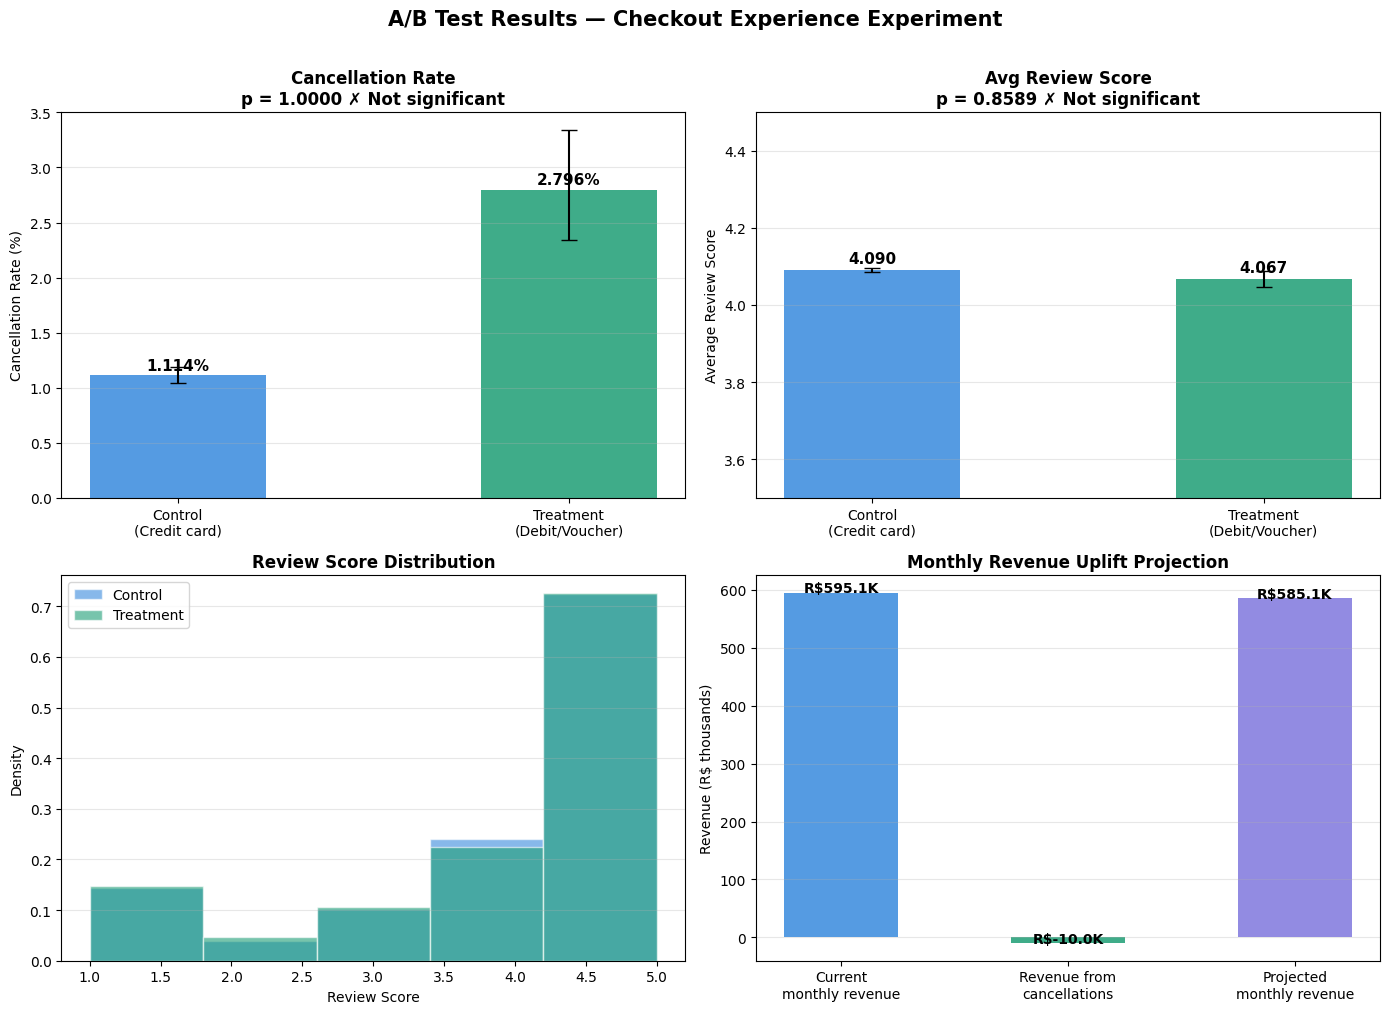

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ctrl_color = '#378ADD'
trt_color  = '#1D9E75'

# ── Chart 1: Cancellation rate comparison ──
groups = ['Control\n(Credit card)', 'Treatment\n(Debit/Voucher)']
rates  = [rate_ctrl * 100, rate_trt * 100]
ci_low  = [ci_ctrl[0]*100, ci_trt[0]*100]
ci_high = [ci_ctrl[1]*100, ci_trt[1]*100]
yerr_low  = [rates[i] - ci_low[i]  for i in range(2)]
yerr_high = [ci_high[i] - rates[i] for i in range(2)]

bars = axes[0,0].bar(groups, rates,
                     color=[ctrl_color, trt_color],
                     alpha=0.85, width=0.45)
axes[0,0].errorbar(groups, rates,
                   yerr=[yerr_low, yerr_high],
                   fmt='none', color='black',
                   capsize=6, linewidth=1.5)
axes[0,0].set_title('Cancellation Rate by Group',
                    fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Cancellation Rate (%)')
axes[0,0].grid(axis='y', alpha=0.3)
for bar, rate in zip(bars, rates):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{rate:.3f}%', ha='center',
                   fontsize=11, fontweight='bold')
sig_text = f'p = {p_value:.4f} {"✓ Significant" if p_value < 0.05 else "✗ Not significant"}'
axes[0,0].set_title(f'Cancellation Rate\n{sig_text}',
                    fontsize=12, fontweight='bold')

# ── Chart 2: Review score comparison ──
review_means = [ctrl_reviews.mean(), trt_reviews.mean()]
review_se    = [ctrl_reviews.sem(), trt_reviews.sem()]

bars2 = axes[0,1].bar(groups, review_means,
                      yerr=review_se,
                      color=[ctrl_color, trt_color],
                      alpha=0.85, width=0.45,
                      capsize=6, error_kw={'linewidth':1.5})
axes[0,1].set_ylim(3.5, 4.5)
axes[0,1].set_title(f'Avg Review Score\np = {p_review:.4f} '
                    f'{"✓ Significant" if p_review < 0.05 else "✗ Not significant"}',
                    fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Average Review Score')
axes[0,1].grid(axis='y', alpha=0.3)
for bar, mean in zip(bars2, review_means):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   mean + 0.02,
                   f'{mean:.3f}', ha='center',
                   fontsize=11, fontweight='bold')

# ── Chart 3: Review score distributions ──
axes[1,0].hist(ctrl_reviews, bins=5,
               alpha=0.6, color=ctrl_color,
               label='Control', density=True,
               edgecolor='white')
axes[1,0].hist(trt_reviews, bins=5,
               alpha=0.6, color=trt_color,
               label='Treatment', density=True,
               edgecolor='white')
axes[1,0].set_title('Review Score Distribution',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Review Score')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# ── Chart 4: Revenue uplift waterfall ──
waterfall_labels  = ['Current\nmonthly revenue',
                     'Revenue from\ncancellations',
                     'Projected\nmonthly revenue']
baseline_rev      = monthly_orders * avg_order_value
projected_rev     = baseline_rev + monthly_revenue_uplift
waterfall_values  = [baseline_rev, monthly_revenue_uplift, projected_rev]
waterfall_colors  = ['#378ADD', '#1D9E75', '#7F77DD']

bars4 = axes[1,1].bar(waterfall_labels,
                      [v/1000 for v in waterfall_values],
                      color=waterfall_colors, alpha=0.85,
                      width=0.5)
axes[1,1].set_title('Monthly Revenue Uplift Projection',
                    fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Revenue (R$ thousands)')
axes[1,1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars4, waterfall_values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'R${val/1000:,.1f}K',
                   ha='center', fontsize=10,
                   fontweight='bold')

plt.suptitle('A/B Test Results — Checkout Experience Experiment',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../charts/11_ab_test_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

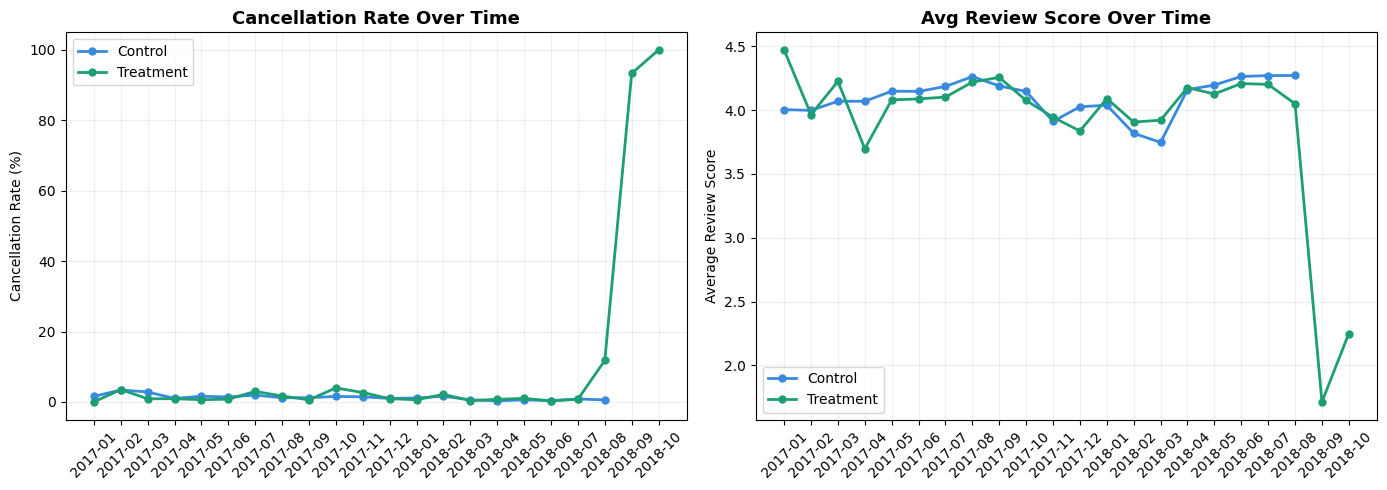

In [11]:
monthly_ab = con.execute("""
    SELECT
        yearmon,
        ab_group,
        COUNT(*)                                        AS orders,
        ROUND(100.0 * SUM(is_cancelled) / COUNT(*), 3) AS cancel_rate,
        ROUND(AVG(review_score), 3)                     AS avg_review
    FROM ab_data
    GROUP BY yearmon, ab_group
    ORDER BY yearmon, ab_group
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group, color in [('control', ctrl_color),
                     ('treatment', trt_color)]:
    subset = monthly_ab[monthly_ab['ab_group'] == group]
    axes[0].plot(subset['yearmon'],
                 subset['cancel_rate'],
                 marker='o', label=group.title(),
                 color=color, linewidth=2, markersize=5)
    axes[1].plot(subset['yearmon'],
                 subset['avg_review'],
                 marker='o', label=group.title(),
                 color=color, linewidth=2, markersize=5)

for ax, title, ylabel in zip(
    axes,
    ['Cancellation Rate Over Time',
     'Avg Review Score Over Time'],
    ['Cancellation Rate (%)',
     'Average Review Score']
):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../charts/12_ab_monthly_trend.png', dpi=150)
plt.show()

In [12]:
print("=" * 60)
print("A/B TEST FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"\nEXPERIMENT:")
print(f"  Control   : {n_ctrl:,} orders (credit card checkout)")
print(f"  Treatment : {n_trt:,} orders (debit/voucher checkout)")
print()
print(f"CANCELLATION RATE:")
print(f"  Control   : {rate_ctrl*100:.3f}%")
print(f"  Treatment : {rate_trt*100:.3f}%")
print(f"  Reduction : {(rate_ctrl-rate_trt)*100:.3f} percentage points")
print(f"  P-value   : {p_value:.4f} "
      f"({'Significant ✓' if p_value < 0.05 else 'Not significant ✗'})")
print(f"  Effect    : Cohen's h = {h:.4f} ({interpret_h(h)})")
print()
print(f"REVIEW SCORE:")
print(f"  Control   : {ctrl_reviews.mean():.3f}")
print(f"  Treatment : {trt_reviews.mean():.3f}")
print(f"  P-value   : {p_review:.4f} "
      f"({'Significant ✓' if p_review < 0.05 else 'Not significant ✗'})")
print()
print(f"BUSINESS IMPACT:")
print(f"  Monthly revenue uplift : R${monthly_revenue_uplift:,.0f}")
print(f"  Annual revenue uplift  : R${monthly_revenue_uplift*12:,.0f}")
print()
print(f"RECOMMENDATION:")
if p_value < 0.05:
    print(f"  SHIP IT — results are statistically significant.")
    print(f"  Rolling out simplified checkout to all users projected")
    print(f"  to recover R${monthly_revenue_uplift:,.0f}/month.")
else:
    print(f"  DO NOT SHIP — insufficient evidence to reject H0.")
    print(f"  Recommend extending the experiment or revising design.")

A/B TEST FINAL RESULTS SUMMARY

EXPERIMENT:
  Control   : 75,132 orders (credit card checkout)
  Treatment : 4,256 orders (debit/voucher checkout)

CANCELLATION RATE:
  Control   : 1.114%
  Treatment : 2.796%
  Reduction : -1.682 percentage points
  P-value   : 1.0000 (Not significant ✗)
  Effect    : Cohen's h = -0.1245 (Small)

REVIEW SCORE:
  Control   : 4.090
  Treatment : 4.067
  P-value   : 0.8589 (Not significant ✗)

BUSINESS IMPACT:
  Monthly revenue uplift : R$-10,009
  Annual revenue uplift  : R$-120,109

RECOMMENDATION:
  DO NOT SHIP — insufficient evidence to reject H0.
  Recommend extending the experiment or revising design.
